# Subsidy capitalisation in a young-adult migration model

**Research question.** How large a subsidy must a state offer young adults to sustain net in-migration once rent feedback is accounted for, and how does this depend on housing supply elasticity? The policy state is Ohio.

**Status: work in progress.** Parameters are placeholders and have not been calibrated. Money is in $k per year.

**Contents**

1. Introduction and setup
2. Data
3. Model
4. Validation (baseline run, comparison with observed migration, unit tests)
5. Experiments
6. Results *(to be completed)*
7. Discussion and limitations *(to be completed)*
8. Interactive demonstration *(to be completed)*

## 1. Introduction and setup

When people move into a state, demand for housing rises and so does rent. A state that subsidises young adults to attract them may therefore see part of the subsidy absorbed by higher rent (capitalisation). The model below represents individual agents choosing among 8 U.S. states, with rent responding to population through a housing supply elasticity, and uses it to study how large a subsidy is needed and how this depends on housing supply.

This differs from Schelling-style models, in which agents move in response to their neighbours and nothing else changes. Here agents respond to prices that their own collective movement changes.

In [1]:
import sys, subprocess
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.model import MigrationModel
from src.params import Params
from utils.data import load_initial_state
from utils.metrics import simulated_net_migration_per_1000, observed_net_migration_per_1000

## 2. Data

Real 2010 state data initialises the model. Observed migration is held back and used only to check the baseline.

### 2.1 (Optional) Re-download the data

The CSV files in `data/` are already included, so **this step is not needed to run the notebook**. To regenerate them from the U.S. Census API, get a free key from <https://api.census.gov/data/key_signup.html>, save it in a `.env` file in the project root as `CENSUS_API_KEY=<your key>`, set `REFRESH_DATA = True` below and run the cell.

In [2]:
REFRESH_DATA = False

if REFRESH_DATA:
    subprocess.run([sys.executable, "-m", "utils.fetch_census"], cwd=ROOT, check=True)
else:
    print("Skipping download; using the CSV files already in data/.")

Skipping download; using the CSV files already in data/.


### 2.2 Initial conditions

Eight states chosen to contrast growth and housing costs. Population is used only to allocate agents to states in proportion; rent and income are 2010 ACS medians converted to $k per year.

In [3]:
init = load_initial_state(ROOT / "data" / "initial_state_2010.csv")
pd.DataFrame({"population": init.population, "rent ($k/yr)": init.rent, "income ($k/yr)": init.wage},
             index=init.names).round(1)

,population,rent ($k/yr),income ($k/yr)
California,37349363.0,14.0,57.7
New York,19392283.0,12.2,54.1
Illinois,12843166.0,10.2,53.0
Ohio,11536182.0,8.2,45.1
Texas,25257114.0,9.6,48.6
Florida,18843326.0,11.4,44.4
Colorado,5049071.0,10.4,54.0
North Carolina,9561558.0,8.8,43.3


## 3. Model

Each year a random fraction of the $N$ agents reconsider where to live. Agent $i$ with income multiplier $z_i$ values state $j$ at

$$u_{ij} = z_i\, w_j - r_j + s_j + \tau\, \frac{n_j}{N} - c\,\mathbf{1}[j \ne \text{current state}]$$

where $w_j$ is the state wage, $r_j$ rent, $s_j$ the subsidy (non-zero only in the policy state), $n_j/N$ the state's population share (social ties, strength $\tau$) and $c$ the migration cost. The agent picks state $j$ with probability $\propto e^{\beta u_{ij}}$.

After everyone has chosen, rent responds to the population change with housing supply elasticity $\varepsilon$:

$$r_j^{t+1} = r_j^{t}\left(\frac{n_j^{t+1}}{n_j^{t}}\right)^{1/\varepsilon}$$

A low $\varepsilon$ means rent rises sharply when people move in, so part of any subsidy is absorbed by rent (capitalisation).

## 4. Validation

### 4.1 A single baseline run (no subsidy)

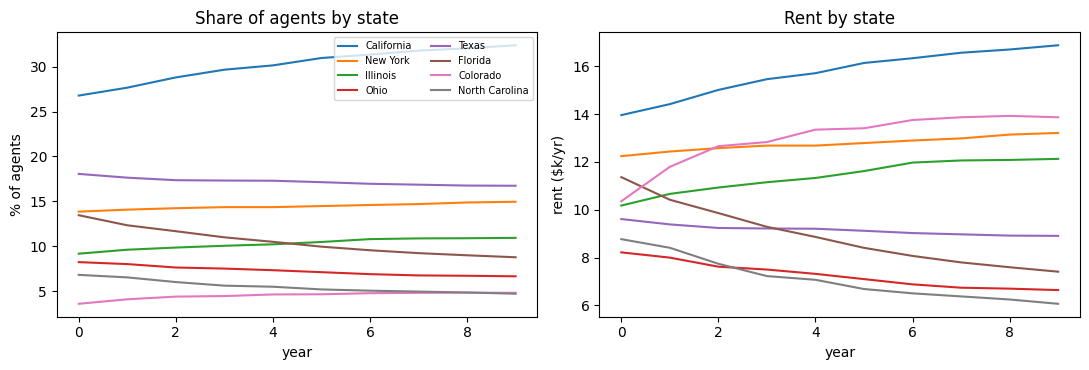

In [4]:
params = Params(n_years=9, seed=0)
h = MigrationModel(params, init).run()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
share = h.population / h.population.sum(axis=1, keepdims=True) * 100
for j, name in enumerate(init.names):
    ax[0].plot(share[:, j], label=name)
    ax[1].plot(h.rent[:, j])
ax[0].set(title="Share of agents by state", xlabel="year", ylabel="% of agents")
ax[1].set(title="Rent by state", xlabel="year", ylabel="rent ($k/yr)")
ax[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### 4.2 Baseline check against observed migration

We compare the simulated cumulative net migration (per 1,000 residents, averaged over 10 seeds, 9 years to match 2010-11 to 2018-19) with the observed net domestic migration. The observed data is *not* used to set up the model. Only the ranking and direction are meaningful, since the simulated system is closed (migration sums to zero across states).

In [5]:
obs = observed_net_migration_per_1000(ROOT / "data" / "observed_net_migration.csv", init)
sim = np.mean([simulated_net_migration_per_1000(
    MigrationModel(replace(params, seed=s), init).run(), params.n_agents) for s in range(10)], axis=0)

cmp = pd.DataFrame({"observed per 1000": obs, "simulated per 1000": sim}, index=init.names).round(1)
print("Spearman rank correlation:", round(cmp.corr(method="spearman").iloc[0, 1], 2))
cmp

Spearman rank correlation: -0.64


,observed per 1000,simulated per 1000
California,-23.9,57.4
New York,-70.0,13.2
Illinois,-66.4,16.7
Ohio,-18.1,-16.8
Texas,44.2,-15.2
Florida,67.9,-46.7
Colorado,68.5,13.0
North Carolina,47.6,-21.6


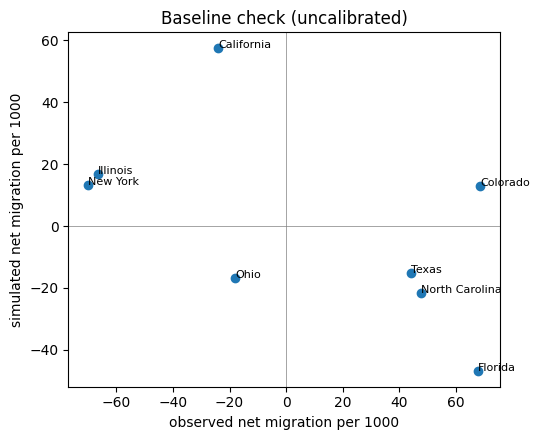

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(cmp["observed per 1000"], cmp["simulated per 1000"])
for name, row in cmp.iterrows():
    ax.annotate(name, (row["observed per 1000"], row["simulated per 1000"]), fontsize=8)
ax.axhline(0, c="grey", lw=.5); ax.axvline(0, c="grey", lw=.5)
ax.set(xlabel="observed net migration per 1000", ylabel="simulated net migration per 1000",
       title="Baseline check (uncalibrated)")
plt.tight_layout(); plt.show()

**Reading this.** With placeholder parameters the baseline does *not* reproduce the real pattern: states with high income net of rent (California, Colorado) attract agents in the model, whereas in reality the Sun Belt states gained and California, New York and Illinois lost. The model only contains wages, rent and ties, and omits other drivers such as jobs growth, climate and taxes. This is an honest limitation of the current version and a point for the next iteration.

### 4.3 Unit tests

The unit tests (conservation of agents, boundary cases, expected directions of effect) run with pytest.

In [7]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT, capture_output=True, text=True)
print(r.stdout[-600:])

## 5. Experiments

### 5.1 Ohio subsidy vs. housing supply elasticity (preview)

A first look at the central question: the same subsidy paid to Ohio residents, under inelastic ($\varepsilon=0.5$) and elastic ($\varepsilon=3$) housing supply, averaged over 10 seeds and 20 years. The full experiment (a sweep and a break-even measure) comes later.

In [8]:
ohio = init.index("Ohio")
rows = []
for eps in (0.5, 3.0):
    for subsidy in (0, 5, 10):
        runs = [MigrationModel(Params(n_years=20, seed=s, subsidy=subsidy, elasticity=eps, policy_state=ohio),
                               init).run() for s in range(10)]
        rows.append({"elasticity": eps, "subsidy ($k/yr)": subsidy,
                     "Ohio agents (year 20)": np.mean([r.population[-1, ohio] for r in runs]),
                     "Ohio rent (year 20, $k/yr)": np.mean([r.rent[-1, ohio] for r in runs])})
pd.DataFrame(rows).round(1)

,elasticity,subsidy ($k/yr),Ohio agents (year 20),"Ohio rent (year 20, $k/yr)"
0,0.5,0,355.8,6.1
1,0.5,5,459.8,10.2
2,0.5,10,552.0,14.8
3,3.0,0,242.4,6.9
4,3.0,5,480.8,8.7
5,3.0,10,1008.9,11.1


Ohio started with roughly 410 of the 5,000 agents and a rent of $8.2k. In this preview the same subsidy brings in far more people, with a smaller rent rise, when supply is elastic.

### 5.2 Planned: subsidy $\times$ elasticity sweep

*To be completed.* Sweep subsidy and elasticity for Ohio across repeated seeds, measure the settled population gain over the zero-subsidy run and the capitalisation share, and add sensitivity checks on migration cost and tie strength.

## 6. Results

*To be completed.*

## 7. Discussion and limitations

*To be completed.* Points to cover: the uncalibrated baseline does not reproduce observed migration (section 4.2), which is treated as a stated limitation; results are scenario comparisons rather than forecasts; wages are fixed and housing supply is a single elasticity parameter; household-level medians stand in for young adults. Details are tracked in `report.md`.

## 8. Interactive demonstration

*To be completed.* Sliders for subsidy and elasticity with live plots, and an animation of flows between states.